In [ ]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import all libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
#Set dataset path
dataset_path = "/content/drive/MyDrive/Disaster_Detection_Project/disaster_dataset"

In [ ]:
#Handle dataset imbalance
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

# Single generator with split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data (80%)
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation data (20%)
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1200 images belonging to 5 classes.
Found 300 images belonging to 5 classes.


In [ ]:
#Data preprocessing
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Create a separate validation generator WITHOUT augmentation
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1200 images belonging to 5 classes.
Found 1500 images belonging to 5 classes.


In [ ]:
#Compute class weights
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [ ]:
#Build Transfer Learning Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

#Train model
history = model.fit(
    train_generator,


    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights
)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 426s 11s/step - accuracy: 0.6267 - loss: 0.9779 - val_accuracy: 0.9087 - val_loss: 0.3333
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.8558 - loss: 0.4378 - val_accuracy: 0.9267 - val_loss: 0.2196
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.8683 - loss: 0.3668 - val_accuracy: 0.9387 - val_loss: 0.1833
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.9033 - loss: 0.2915 - val_accuracy: 0.9493 - val_loss: 0.1494
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.9183 - loss: 0.2502 - val_accuracy: 0.9453 - val_loss: 0.1484
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.9225 - loss: 0.2228 - val_accuracy: 0.9453 - val_loss: 0.1457
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9275 - loss: 0.2038 - val_accuracy: 0.9487 - val_loss: 0.1418
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.9250 - loss: 0.1957 - val_accuracy: 0.9607 - val

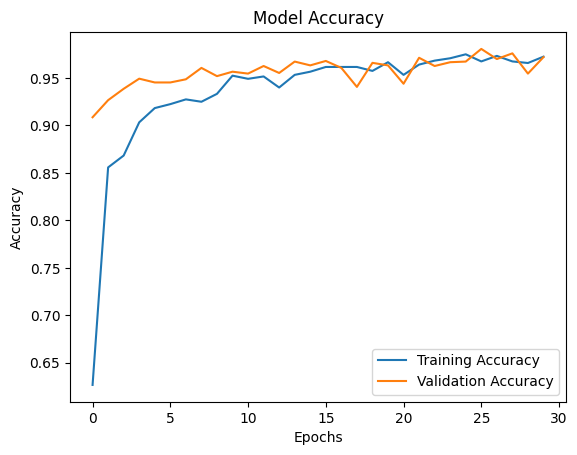

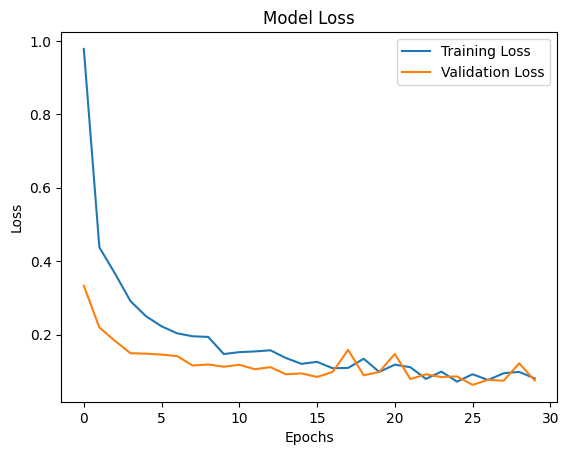

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step


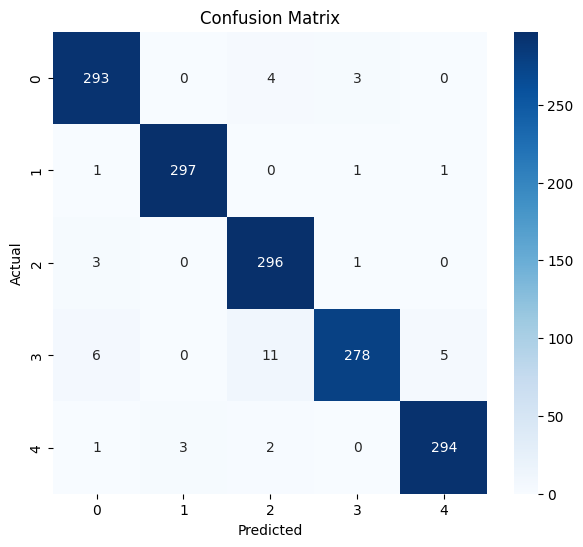

In [ ]:
#Confusion matrix

Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, cmap="Blues" , fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#Precision, Recall, F1 Score
print(classification_report(
    val_generator.classes,
    y_pred,
    target_names=list(val_generator.class_indices.keys())
))

              precision    recall  f1-score   support

  earthquake       0.96      0.98      0.97       300
        fire       0.99      0.99      0.99       300
       flood       0.95      0.99      0.97       300
   landslide       0.98      0.93      0.95       300
      normal       0.98      0.98      0.98       300

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



In [ ]:
import cv2

In [ ]:
#Upload a test image
from google.colab import files
uploaded = files.upload()

Saving landslide 2.webp to landslide 2.webp


In [ ]:
#Load the image
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
#Gradcam Function
def gradcam(image, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

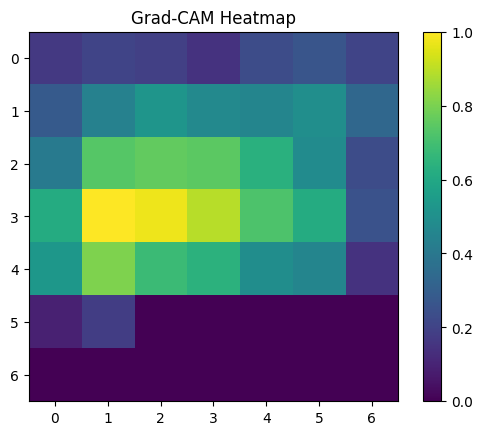

In [ ]:
#Generate GradCam Heatmap
heatmap = gradcam(img_array, model, "Conv_1")

plt.imshow(heatmap)
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

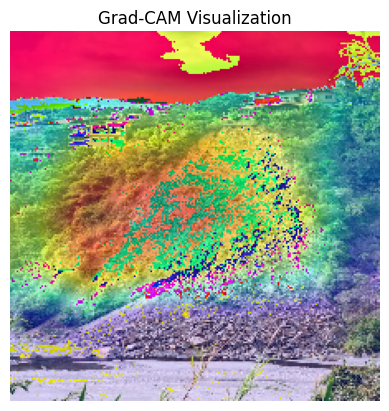

In [ ]:
#Overlay heatmap on original image
img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original,(224,224))

heatmap = cv2.resize(heatmap,(224,224))
heatmap = np.uint8(255*heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img_original

plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Visualization")
plt.axis("off")
plt.show()

In [ ]:
#Severity estimation
def severity_level(confidence):

    if confidence > 0.85:
        return "High Damage"

    elif confidence > 0.60:
        return "Moderate Damage"

    else:
        return "Low Damage"

Saving 360_F_100861147_G7l8U6RDS4wdb9PQ9aaMXBINkDqD2a18.jpg to 360_F_100861147_G7l8U6RDS4wdb9PQ9aaMXBINkDqD2a18 (2).jpg


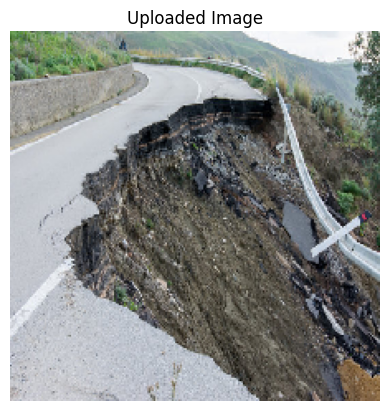

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Disaster Type: landslide
Confidence: 0.6546798
Severity: Moderate Damage


In [ ]:
#Test the model on the image
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load and display image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# Prepare image for prediction
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

# Severity estimation
def severity_level(label,conf):
  if label =="normal":
    return "No Damage"
  else:
    if conf > 0.85:
        return "High Damage"
    elif conf > 0.60:
        return "Moderate Damage"
    else:
        return "Low Damage"

print("Disaster Type:", predicted_class)
print("Confidence:", confidence)
print("Severity:", severity_level(predicted_class,confidence))

Saving download (1).jpg to download (1).jpg


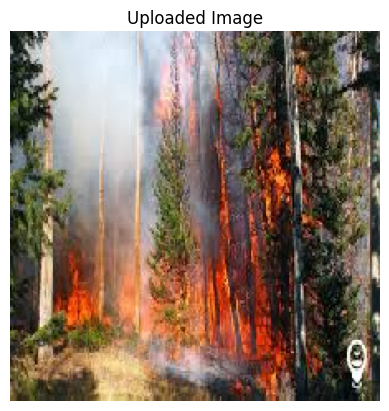

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Disaster Type: fire
Confidence: 0.88067746
Severity: High Damage


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load and display image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# Prepare image for prediction
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

# Severity estimation
def severity_level(conf):
    if conf > 0.85:
        return "High Damage"
    elif conf > 0.60:
        return "Moderate Damage"
    else:
        return "Low Damage"

print("Disaster Type:", predicted_class)
print("Confidence:", confidence)
print("Severity:", severity_level(confidence))

Saving images.jpg to images.jpg


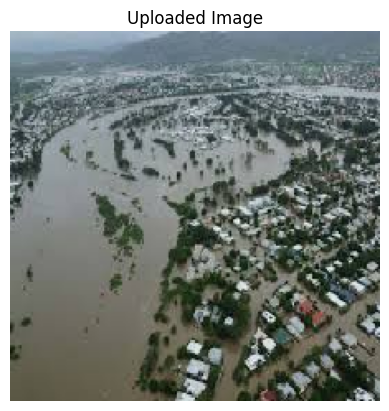

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Disaster Type: flood
Confidence: 0.9991738
Severity: High Damage


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load and display image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# Prepare image for prediction
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

# Severity estimation
def severity_level(conf):
    if conf > 0.85:
        return "High Damage"
    elif conf > 0.60:
        return "Moderate Damage"
    else:
        return "Low Damage"

print("Disaster Type:", predicted_class)
print("Confidence:", confidence)
print("Severity:", severity_level(confidence))